# AMS563 Homework 1 (Spring 2026) - Part A

This assignment is for AMS563, Spring 2026. Complete all tasks in this notebook. Keep the structure unchanged and run all cells before submission.


## Question 1: Linear Regression (30 points)

My friend wants to solve a linear regression problem. He asked me to help him out. He is going to give me a matrix, let's call that matrix $\mathbf{X} \in \mathbb{R}^{100 \times 4}$, which has 100 rows and 4 columns. The 100 is the number of samples, and 4 is the number of features. Let's assume that $\mathbf{x}_i \in \mathbb{R}^4$ is a feature vector of the sample $i$ and let's use $y_i \in \mathbb{R}$ as the target for the sample $i$. I am going to use $\mathbf{y} \in \mathbb{R}^{100}$ to denote the vector containing the target of all samples.

He wants to solve the following regression:

$$
\cal{L}(\mathbf{w}) = \sum_{i=1}^N { \| y_i - x_i^T \mathbf{w}  \|_2^2  }
$$

Where $N=100$ is the total number of samples and $\mathbf{w} \in \mathbb{R}^4$ is the unknown parameters of the regression and $\cal{L}(\mathbf{w})$ is the regression loss which is a function of $\mathbf{w}$.

**Q1.1 (warm-up)**: Write down the regression in a matrix format. Make sure your notation should only involve $\mathbf{y}$, $\mathbf{w}$, and $\mathbf{X}$.

**Answer: $$
\mathcal{L}(\mathbf{w}) = \| \mathbf{y} - \mathbf{Xw} \|_2^2
$$

**Q1.2**: Now, take a derivative for $\mathbf{w}$ and write down how the optimal solution in the form of a system of linear equations. As a reminder, the system of the linear equation looks like $\mathbf{A} \mathbf{z} = \mathbf{b}$, where $\mathbf{A}$ and $\mathbf{b}$ are known and $\mathbf{z}$ is unknown. What are the $\mathbf{A}$ and $\mathbf{b}$ in the case of linear regression:

**Answer: $$
\mathcal{L}(\mathbf{w}) = (\mathbf{y} - \mathbf{Xw})^T(\mathbf{y} - \mathbf{Xw})
$$

$$
\nabla_{\mathbf{w}} \mathcal{L}(\mathbf{w}) =
-2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\mathbf{w}
$$

Set the derivative to zero:

$$
\mathbf{X}^T\mathbf{X}\mathbf{w} = \mathbf{X}^T\mathbf{y}
$$

Linear system form $\mathbf{A}\mathbf{z} = \mathbf{b}$:

$$
\mathbf{A} = \mathbf{X}^T\mathbf{X}, \quad
\mathbf{z} = \mathbf{w}, \quad
\mathbf{b} = \mathbf{X}^T\mathbf{y}
$$

**Q1.3 (bonus)**: What is the smallest eigenvalue of the matrix $\mathbf{A}$?

**Answer**: $$
\lambda_{\min}(\mathbf{A})
= \lambda_{\min}(\mathbf{X}^T\mathbf{X})
= \sigma_{\min}(\mathbf{X})^2 \ge 0
$$



## Question 2: Logistic Regression (40 points)

In this section we will train a classifier to predict if a neonate is preterm based on volume measures of 86 brain volumes. We will code up and train a logistic regression classifier from scratch.

### Import the data
The data are in the file "data_hw1_q1.pkl", download it [here](https://drive.google.com/file/d/1Z2b45PHoH5QcNP3mQzTDiROfd8xF2pUN/view?usp=sharing). The column y indicates whether each data set was collected from a term or preterm baby (scanned at term equivalent age). The data represent mean vales of three different types of cortical imaging data: cortical thickness, cortical folding and cortical myelination, all averaged within 100 regions of interest ROIS on the surface. This gives 300 features in total.

<img src="https://raw.githubusercontent.com/lisun-ai/EC500/master/imgs/cortical_rois.png" alt="Drawing" style="width: 800px;"/>

There are 1000 babies, including 900 terms and 100 preterms. The code below loads the file and splits the data randomly into a train and test set. The data is transposed such that the rows reflect features and the columns examples (as expected from the lectures notation). A row of ones is added to each dataset to allow modelling of the bias term.

Run the code, be sure to understand what each line is doing.

In [ ]:
import pickle
import numpy as np
from sklearn.model_selection import train_test_split

# Read the data
data = pickle.load(open('data_hw1_q1.pkl', 'rb'))
X, y = data['X'], data['y']

# create a test and train split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Create feature matrix
X_train = X_train.T
X_test = X_test.T

bias_row=np.ones((1, X_train.shape[1]))
print(X_train, X_test, X_train.shape, X_test.shape) # (300, 900) (300, 100)

print(bias_row.shape)
X_train = np.concatenate((np.ones((1, X_train.shape[1])), X_train))
X_test = np.concatenate((np.ones((1, X_test.shape[1])), X_test))

# set variables for numbers of feature and examples to improve readabiity of code
n_features = X_train.shape[0] - 1
n_examples = X_train.shape[1]

print('Dimension of X is ', X_train.shape)  # (301, 900)
print('Dimension of y is ', y_train.shape)
print('Number of features', n_features)
print('Number of examples', n_examples)
print("Number of y_train == 1", np.sum(y_train == 1))
print("Number of y_train == 0 ", np.sum(y_train == 0))
print("Number of y_test == 1", np.sum(y_test == 1))
print("Number of y_test == 0 ", np.sum(y_test == 0))

[[-0.51105889  0.97879333 -0.48976802 ...  0.75291609  0.30179744
  -1.34655806]
 [ 0.80110565 -0.37481065  3.48161383 ...  1.33332637 -0.9610818
   3.92679047]
 [-1.14694125 -0.91816584  0.01460454 ...  0.05068875  0.00758647
  -2.20920686]
 ...
 [-0.19632155 -0.39613437 -0.5744995  ... -1.74503015 -0.33166294
   0.40031371]
 [ 2.36585358 -1.2890315   7.24529458 ...  2.77658981 -0.01201424
  -4.7539416 ]
 [ 1.20167996  0.27137957 -2.12397658 ...  0.71497903 -0.67332788
   1.2639654 ]] [[ 1.12114157e+00  8.86493799e-01  1.45317665e+00 ... -9.26891866e-01
   4.66982731e-01  7.46206585e-01]
 [ 1.41423885e+00  4.78143635e+00 -1.42655953e+00 ... -1.25155222e+00
  -1.60231431e+00  4.73635683e+00]
 [ 3.64206483e-01  6.17871041e-01  7.91465582e-01 ...  8.53289204e-01
  -2.71168513e-03 -1.31459514e-01]
 ...
 [ 1.05894205e+00  2.75055179e-01  4.77927317e-01 ...  5.47523774e-02
  -3.48459765e-01 -1.21533341e+00]
 [-6.07894165e-01  2.39088947e+00 -1.62608227e+00 ... -2.33584439e+00
   2.11779878e

### Eyeball the data
The following code plots histograms of a single feature (brain volume) for preterms vs terms. Run the code for a few different values of 'feature'.

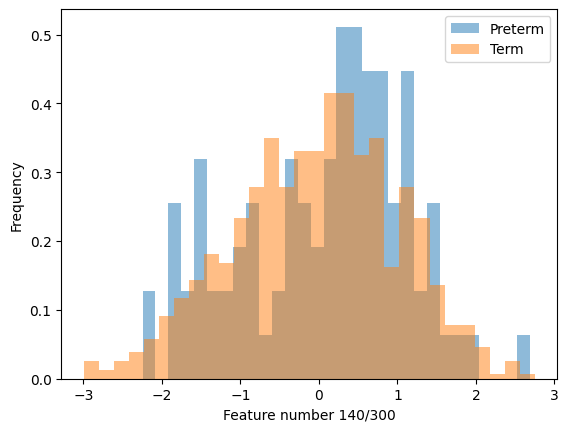

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

#### STUDENT'S CODE HERE ####
# try values between 0 and 300
feature = 140

plt.hist(X_train[feature+1, y_train==0], bins=30, alpha=0.5, density=True)
plt.hist(X_train[feature+1, y_train==1], bins=30, alpha=0.5, density=True)
plt.xlabel('Feature number {}/300'.format(feature))
plt.ylabel('Frequency')
plt.legend(['Preterm','Term'])
plt.show()

### Model

Our predictions for a single output (ie single target) can be written:
$$ f= f(z) = \dfrac{1}{1+e^{-z}} $$

Where, for logistic regression, $f$ is the sigmoid function and:

$$z=w_0 + w_1x_1 + w_2x_2 +w_3x_3....+w_m x_m$$

Here $w_0$ is the bias term, $w_1,w_2....w_m$ are the weights;, $m$ is the number of features and $\mathbf{x}$ is a single example from our training set $X \in \mathbb{R}^{m\times n}$ (of size $ m\times n$).

### Implementation of the forward pass

We could calculate $f$ in one line of code, but it will come in handy when considering backpropagation later to consider the computation in stages, with each stage consisting of a simple module:

$$
\begin{align}
\mathbf{Z} &= \mathbf{W} \mathbf{X} \\
\mathbf{F}=f(\mathbf{Z}) &= \dfrac{1}{1+e^{-\mathbf{Z}}}
\end{align}
$$

Implemented using vectorisation.

### Task 2.1 Estimate $\mathbf{Z}$:

Write a function $z(w,x)$ that uses vectorisation to linearly transform data matrix $\mathbf{X}$ using the weights matrix $\mathbf{W}$.

**Hint** $\mathbf{X}$ has size $m_{features} \times n_{examples}$. What size should the output matrix $\mathbf{Z}$ be?


In [ ]:
def z(w, x):
    Z = np.dot(w, x)
    return Z

Create an matrix of zeros to initialise $\mathbf{W}$. Verify your function $z(w,x)$ gives an output of the expected dimension.

- What dimension should $\mathbf{W}$ be?

**Answer**: W should have shape (1, m_features)

In [ ]:
w = np.zeros((1, X_train.shape[0]))

output = z(w, X_train)

print(f"dimension of W: {w.shape}")
print(f"dimension of the product WX: {output.shape}")

dimension of W: (1, 301)
dimension of the product WX: (1, 900)


### Task 2.2 Implement Sigmoid function f:

Now write a function to compute $f(\mathbf{Z})$, our logistic regression function:

In [ ]:
def f(z):
    sigmoid = 1 / (1 + np.exp(-z))
    return sigmoid

Verify your softmax looks right by running this plotting code:

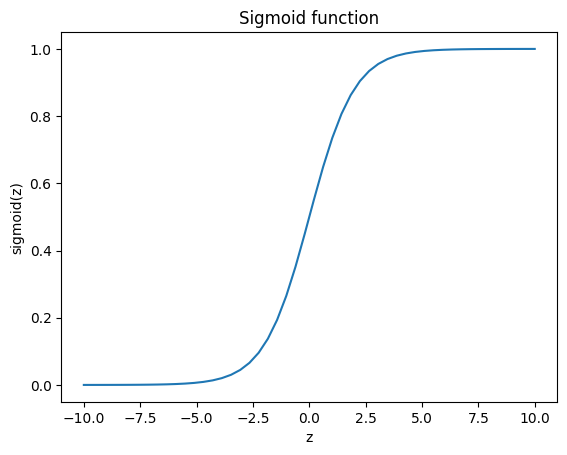

In [ ]:
inputs = np.linspace(-10,10)
outputs = f(inputs)
plt.plot(inputs, outputs)
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('Sigmoid function')
plt.show()

We're now in a position to compute some predictions $\mathbf{\hat{y}}$:

In [ ]:
y_pred = f(z(w,X_train))

Are these predictions any good? Let's take a look at the accuracy:

In [ ]:
def accuracy(y, y_pred, threshold = 0.5):
    y_pred_thresholded = y_pred > threshold
    correct_predictions = np.sum(y==y_pred_thresholded)
    total_predictions = np.shape(y)
    accuracy = 100 * correct_predictions / total_predictions
    return accuracy

In [ ]:
y_pred = f(z(w, X_train))
print(accuracy(y_train, y_pred))

[10.55555556]


Look at the predictions ```y_pred```, what does this initial prediction return and why? Enter your answer in the box below

**Answer here**: The initial prediction returns values of 0.5 for every example because all weights in $\mathbf{W}$ were initialized to zero.

### Task 2.3 Implement Cross Entropy Loss:

Accuracy is easy to intepret, but can't be optimised using gradient descent. We need a measure of our prediction quality that can be. A typical loss function used in  classification problems is cross-entropy:

$$L(y_i,f(z_i)) = - y_i \ln(f(z_i)) - (1-y_i) \ln(1-f(z_i))$$

This may be implemented using vectorisation as:

$$L(\mathbf{Y},\mathbf{F}) = - \mathbf{Y} \ln(\mathbf{F}) - (1-\mathbf{Y}) \ln(1-\mathbf{F})$$

This returns a vector of losses $(L_1,L_2....L_n)$ estimated for all training examples n. We require the total cost estimated as:

$$ J(\mathbf{W})= \frac{1}{n} \sum_i L_i(y_i,f(z_i)) $$

Implement the Cross-Entropy loss and return the total cost (**hint** using numpy functions for vectorisation).

In [ ]:
def loss(y, y_pred):
    epsilon = 1e-5
    L = -np.mean(
        y * np.log(y_pred + epsilon) +
        (1 - y) * np.log(1 - y_pred + epsilon)
    )
    return L

In [ ]:
epsilon = 1e-5
total_loss= loss(y_train,y_pred)
print(total_loss)

0.6931271807599427


### Task 2.4 Implement Forward Pass

We now have all the components of the forward pass for our logistic regression. Write a full forward pass that takes data, targets and a weight matrix and performs the forward pass to calculate the loss:

**hint - One line** You have already defined all the vectorised functions you need above

In [ ]:
def forward_pass(X, y, w):
    F = f(z(w, X))
    print('Loss: {}'.format(loss(y, F)))
    print('Accuracy: {}'.format(accuracy(y, F)))

In [ ]:
#perform forward pass
forward_pass(X_train,y_train, w)

Loss: 0.6931271807599427
Accuracy: [10.55555556]


### Task 2.5 Implement backwards pass

We're now ready to try and adjust our parameters $\mathbf{W}$ in order to optimise our predictions. First, calculate the change in our loss function with respect to our parameters, $\dfrac{\partial L}{\partial \mathbf{W}}$.


**Answer here**: The change (gradient) of the loss with respect to the weights is

$$
\Delta \mathbf{W}
= \frac{\partial J}{\partial \mathbf{W}}
= \frac{1}{n}(\mathbf{F} - \mathbf{Y}) \mathbf{X}^T
$$

Let's calculate the gradient of our loss, $\dfrac{\partial L}{\partial \mathbf{W}}$, for a **single** input, $\mathbf{x}$. Fill in the calculations of the backward pass in the following code:

In [ ]:
# initialize weights (1 x m_features)
w = np.zeros((1, X_train.shape[0]))

# select just the first example here
x = X_train[:,0]
y_single = y_train[0]
print('The true value of y is: {}'.format(y_single))

# calculate the forward pass, and store the outputs at each stage
Z = z(w, x)
F = f(Z)
print('Our prediction for y is: {}'.format(F))

# estimate the loss
l = loss(y_single, F)
print('The loss is {}'.format(l))

# backwards pass (gradient for a single example)
dl_dw = (F - y_single) * x

The true value of y is: 0
Our prediction for y is: [0.5]
The loss is 0.6931271807599427


We can check this gradient calculation is correct by updating our weights vector and looking at our new prediction:

In [ ]:
# The gradient is in the direction of increasing loss,
# so we subtract the gradient from w.
learning_rate = 0.001
w = w - learning_rate * dl_dw
Z = z(w,x)
F = f(Z)
l = loss(y_single,F)
print('Our updated prediction for y is: {}'.format(F))
print('The loss is {}'.format(l))

Our updated prediction for y is: [0.41309308]
The loss is 0.5328720075027558


Looks good! We have only updated $\mathbf{w}$ using information from a single data point. In practice we want to use all the data available.

**To do**
1. Perform the backward pass again, but this time with vectorisation. Check that the shape of `dL_dw` is what you would expect.
2. Estimate the full cost over all training examples

In [ ]:
w = np.zeros((1, X_train.shape[0]))

# calculate the forward pass, and store the outputs at each stage
Z = z(w, X_train)
F = f(Z)
l = loss(y_train, F)

# implement the backward pass (vectorized)
dL_dw = np.dot((F - y_train), X_train.T)
print('dL_dw has shape: {}'.format(dL_dw.shape))

grad_mean = dL_dw / n_examples

dL_dw has shape: (1, 301)


###  Putting it all together: the training loop

We now have everything we need to train a logistic regression classifier using backprop. Fill out the training loop below using the code you have already written in this notebook.

In [ ]:
# initialise w to all zeros
w = np.zeros((1, X_train.shape[0]))

# mean centre and normalise X
X_centred = np.ones_like(X_train)
X_centred[1:] = (X_train[1:] - X_train[1:].mean(axis=1, keepdims=True)) / (X_train[1:].std(axis=1, keepdims=True) + epsilon)

# we'll store the loss and accuracy in these lists during training
loss_record = []
accuracy_record = []

num_iterations = 2000

for i in range(num_iterations):
    # forward pass - get predictions
    F = f(z(w, X_centred))

    # store the loss/accuracy at this iteration
    cur_loss = loss(y_train, F)
    cur_accuracy = accuracy(y_train, F)
    loss_record.append(cur_loss)
    accuracy_record.append(cur_accuracy)

    # backwards pass to get gradients
    dL_dw = np.dot((F - y_train), X_centred.T)
    grad_mean = dL_dw / n_examples

    # update the weights
    w = w - learning_rate * grad_mean

Max training acc: 92.66666666666667
Min training loss: 0.4538936096629053


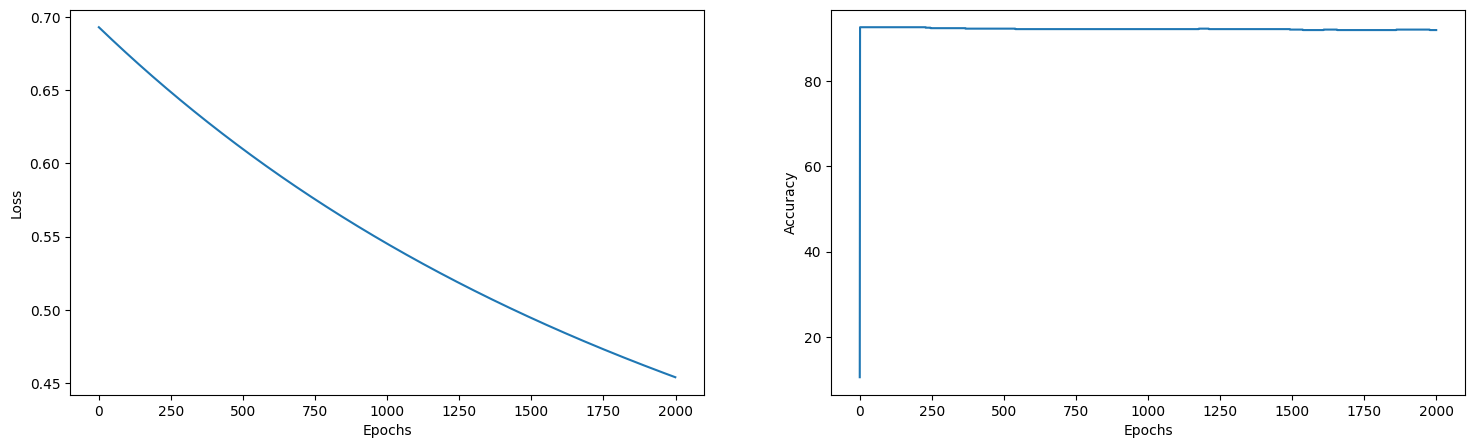

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (18,5))
ax[0].plot(loss_record)
ax[1].plot(accuracy_record)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')

print('Max training acc:', np.max(accuracy_record))
print('Min training loss:', np.min(loss_record))
plt.show()

###  Now Testing on left out set

**Task:** test the performance of your logistic regression on your left out test set

In [ ]:
# centre X
X_test_centred = np.ones_like(X_test)
X_test_centred[1:] = (X_test[1:] -X_test[1:].mean(axis=1,keepdims=True)) / (X_test[1:].std(axis=1,keepdims=True)+epsilon)

Z_test = z(w,X_test_centred)
F_test = f(Z_test)
l = loss(y_test,F_test)

print('loss:', l)
print('final acc:',accuracy(y_test,F_test))

loss: 0.4851104333125064
final acc: [90.]


###  Task 2.7 (bonus) Evaluation with more metrics
Sometimes accuracy alone cannot give a holistic view of perfomance, especially when the classes are imbalanced. In this case, we can use some other metrics, including AUROC, average precision, F1 score to measure the performance.

#### Plot AUROC curve
In this task, you are requested to plot the AUROC (area under the receiver operating characteristic) curve. Some explanation about AUROC can be found [here](https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc).

In [ ]:
def calculate_auroc(actual, predicted):
    # Sort the predictions in descending order
    sorted_indices = np.argsort(predicted)[::-1]
    actual_sorted = actual[sorted_indices]

    # Count the positive and negative examples
    num_positives = np.sum(actual == 1)
    num_negatives = np.sum(actual == 0)

    # Initialize variables
    true_positives = 0
    false_positives = 0
    tpr_list = [0]
    fpr_list = [0]

    # Iterate through the sorted predictions
    for i in range(len(sorted_indices)):
        if actual_sorted[i] == 1:
            true_positives += 1
        else:
            false_positives += 1

        # Calculate True Positive Rate (Sensitivity) and False Positive Rate
        tpr = true_positives / num_positives
        fpr = false_positives / num_negatives

        # Append values to lists for plotting
        tpr_list.append(tpr)
        fpr_list.append(fpr)

    # Calculate AUROC
    auroc = np.trapz(tpr_list, fpr_list)

    return auroc, tpr_list, fpr_list

/tmp/ipython-input-3039745559.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auroc = np.trapz(tpr_list, fpr_list)


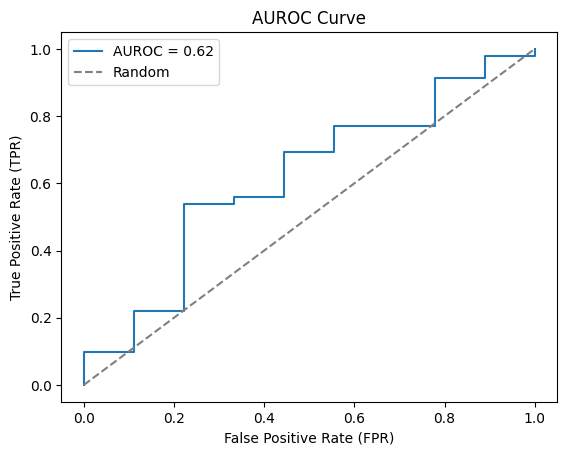

In [ ]:
auroc, tpr_list, fpr_list = calculate_auroc(y_test, F_test.reshape((-1,)))

# Plot the AUROC curve
plt.plot(fpr_list, tpr_list, label=f'AUROC = {auroc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('AUROC Curve')
plt.legend()
plt.show()

Does the accuracy and AUROC look good? Discuss the results below.

**Answer: The AUROC is higher than the accuracy, which suggests the model is better at separating the two classes than the single accuracy value implies. Since AUROC evaluates performance across all possible thresholds, it shows that the model is ranking positive vs. negative examples well even if the fixed classification cutoff lowers the measured accuracy.

Overall, the results suggest the model has learned useful patterns, and the higher AUROC indicates stronger discriminative ability than accuracy alone might suggest.

In [ ]:
print('predict y == 1', np.sum(F_test > 0.5))
print('predict y == 0', np.sum(F_test <= 0.5))

predict y == 1 99
predict y == 0 1
